In [403]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import geopandas as gpd
from shapely.geometry import Point

## Содержание датафрейма
##### Для расчёта EBITDA буду использовать формулу, используемую в российском сегменте рынка: 
##### Вр — СТ + НП + Пр + А, где
##### Вр - выручка от реализации продукции (код - 2110)
##### СТ - себестоимость продукции (код - 2120)
##### НП - налог на прибыль (код - 2410)
##### Пр - проценты по займам (код - 2330)
##### А - амортизация основных средств и нематериальных активов (код - 1150 и 1110 соответственно)

##### Помимо вышеперечисленного возьму показатель чистой прибыли для оценки рентабельности отрасли (код - 2400)


### Загрузка списка организаций

In [404]:
# Загружу таблицу с ИНН интересующих организаций
# Нужны малые и средние предприятия, занимающиеся строительством жилых и нежилых зданий
inns = pd.read_excel('https://github.com/garvelloken38/Construction_companies/blob/dev/inns.xlsx?raw=true', engine = 'openpyxl')

In [405]:
inns['Категория'].value_counts()

Категория
Малое предприятие      10183
Среднее предприятие      894
Name: count, dtype: int64

In [406]:
inns['Основной вид деятельности'].value_counts()

Основной вид деятельности
41.20 Строительство жилых и нежилых зданий    9413
41.2 Строительство жилых и нежилых зданий     1664
Name: count, dtype: int64

In [407]:
inns_list = inns['ИНН'].tolist()

### Создание датафрейма

In [408]:
session = requests.Session()

In [409]:
headers ={'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/138.0.0.0 Safari/537.36'}

In [53]:
# predresponse = session.get('https://bo.nalog.gov.ru/advanced-search/organizations?\
# allFieldsMatch=false&inn=7713011336&page=0&size=20', headers = headers).json()

In [54]:
# org_id = predresponse['content'][0]['id']

In [55]:
# response = session.get(f'https://bo.nalog.gov.ru/nbo/organizations/{org_id}/bfo/',
#                        headers = headers).json()

In [117]:
# row_dict = {}

# for i in [0, 2, 4]:

#     row_dict[f'non_mat_assets_{2024 - i}'] = response[i]['typeCorrections'][0]['correction']['balance']['current1110']
#     row_dict[f'fixed_assets_{2024-i}'] = response[i]['typeCorrections'][0]['correction']['balance']['current1150']
#     row_dict[f'rev_{2024-i}'] = response[i]['typeCorrections'][0]['correction']['financialResult']['current2110']
#     row_dict[f'cost_price_{2024-i}'] = response[i]['typeCorrections'][0]['correction']['financialResult']['current2120']
#     row_dict[f'tax_{2024-i}'] = response[i]['typeCorrections'][0]['correction']['financialResult']['current2410']
#     row_dict[f'percent_{2024-i}'] = response[i]['typeCorrections'][0]['correction']['financialResult']['current2330']
#     row_dict[f'profit_{2024-i}'] = response[i]['typeCorrections'][0]['correction']['financialResult']['current2400']

#     row_dict[f'non_mat_assets_{2024-(1+i)}'] = response[i]['typeCorrections'][0]['correction']['balance']['previous1110']
#     row_dict[f'fixed_assets_{2024-(1+i)}'] = response[i]['typeCorrections'][0]['correction']['balance']['previous1150']
#     row_dict[f'rev_{2024-(1+i)}'] = response[i]['typeCorrections'][0]['correction']['financialResult']['previous2110']
#     row_dict[f'cost_price_{2024-(1+i)}'] = response[i]['typeCorrections'][0]['correction']['financialResult']['previous2120']
#     row_dict[f'tax_{2024-(1+i)}'] = response[i]['typeCorrections'][0]['correction']['financialResult']['previous2410']
#     row_dict[f'percent_{2024-(1+i)}'] = response[i]['typeCorrections'][0]['correction']['financialResult']['previous2330']
#     row_dict[f'profit_{2024-(1+i)}'] = response[i]['typeCorrections'][0]['correction']['financialResult']['previous2400']


In [118]:
# df = pd.DataFrame(columns = range(42))

In [119]:
# df.loc[0] = row_dict.values()

In [120]:
# df
# Протестировал работу парсера на одной фирме - группы Пик

,0,1,2,3,4,5,6,7,8,9,...,32,33,34,35,36,37,38,39,40,41
0,190610.0,1436451.0,60445765.0,11602778.0,9437259.0,3602732.0,3038370.0,51529.0,1783287.0,39960617.0,...,-1347720.0,5025879.0,26471323.0,54047.0,343315.0,24571955.0,8025403.0,-364755.0,8061300.0,306264.0


In [118]:
# Сам скрипт 

df = pd.DataFrame(columns = range(45))
s=0

for inn in inns_list:

    predresponse = session.get(f'https://bo.nalog.gov.ru/advanced-search/organizations?\
                               allFieldsMatch=false&inn={inn}&page=0&size=20', headers = headers).json()
    
    try:
        org_id = predresponse['content'][0]['id']
    except:
        continue

    response = session.get(f'https://bo.nalog.gov.ru/nbo/organizations/{org_id}/bfo/',
                           headers = headers).json()
    try:
        address = response[0]['organizationInfo']['address']
    except:
        address = float('Nan')

    row_dict = {'INN': str(inn), 'org_id': str(org_id), 'address': address}

    for i in [0, 2, 4]:
        # чётные года
        try:
            row_dict[f'non_mat_assets_{2024 - i}'] = response[i]['typeCorrections'][0]['correction']['balance']['current1110']
        except:
            row_dict[f'non_mat_assets_{2024 - i}'] = float('Nan')
        try:
            row_dict[f'fixed_assets_{2024-i}'] = response[i]['typeCorrections'][0]['correction']['balance']['current1150']
        except:
            row_dict[f'fixed_assets_{2024-i}'] = float('Nan')
        try:
            row_dict[f'rev_{2024-i}'] = response[i]['typeCorrections'][0]['correction']['financialResult']['current2110']
        except:
            row_dict[f'rev_{2024-i}'] = float('Nan')
        try:
            row_dict[f'cost_price_{2024-i}'] = response[i]['typeCorrections'][0]['correction']['financialResult']['current2120']
        except:
            row_dict[f'cost_price_{2024-i}'] = float('Nan')
        try:
            row_dict[f'tax_{2024-i}'] = response[i]['typeCorrections'][0]['correction']['financialResult']['current2410']
        except:
            row_dict[f'tax_{2024-i}'] = float('Nan')
        try:
            row_dict[f'percent_{2024-i}'] = response[i]['typeCorrections'][0]['correction']['financialResult']['current2330']
        except:
            row_dict[f'percent_{2024-i}'] = float('Nan')
            
        try:
            row_dict[f'profit_{2024-i}'] = response[i]['typeCorrections'][0]['correction']['financialResult']['current2400']
        except:
            row_dict[f'profit_{2024-i}'] = float('Nan')
            

        # нечётные года
        try:
            row_dict[f'non_mat_assets_{2024-(1+i)}'] = response[i]['typeCorrections'][0]['correction']['balance']['previous1110']
        except:
            row_dict[f'non_mat_assets_{2024-(1+i)}'] = float('Nan')
        
        try:
            row_dict[f'fixed_assets_{2024-(1+i)}'] = response[i]['typeCorrections'][0]['correction']['balance']['previous1150']
        except:
            row_dict[f'fixed_assets_{2024-(1+i)}'] = float('Nan')
        
        try:
            row_dict[f'rev_{2024-(1+i)}'] = response[i]['typeCorrections'][0]['correction']['financialResult']['previous2110']
        except:
            row_dict[f'rev_{2024-(1+i)}'] = float('Nan')
        
        try:
            row_dict[f'cost_price_{2024-(1+i)}'] = response[i]['typeCorrections'][0]['correction']['financialResult']['previous2120']
        except:
            row_dict[f'cost_price_{2024-(1+i)}'] = float('Nan')
        
        try:
            row_dict[f'tax_{2024-(1+i)}'] = response[i]['typeCorrections'][0]['correction']['financialResult']['previous2410']
        except:
            row_dict[f'tax_{2024-(1+i)}'] = float('Nan')

        try:
            row_dict[f'percent_{2024-(1+i)}'] = response[i]['typeCorrections'][0]['correction']['financialResult']['previous2330']
        except:
            row_dict[f'percent_{2024-(1+i)}'] = float('Nan')

            
        try:
            row_dict[f'profit_{2024-(1+i)}'] = response[i]['typeCorrections'][0]['correction']['financialResult']['previous2400']
        except:
            row_dict[f'profit_{2024-(1+i)}'] = float('Nan')
    df.loc[s] = row_dict.values()
    s+=1

In [133]:
df = df.rename(columns = dict(zip(range(45), row_dict.keys())))

In [149]:
df.to_csv('./construction_orgs.csv', index = False)

### Исследование датафрейма

In [410]:
builders = pd.read_csv('https://github.com/garvelloken38/Construction_companies/blob/dev/construction_orgs.csv?raw=true')

In [411]:
builders = builders.dropna(how = 'all')

In [412]:
# Заменю пропущенные значения на нули 
# C одной стороны это исказит данные
# С другой - данные теряются, так как пропущенные значения есть практически в каждом ряду
builders[[col for col in builders.columns if col not in ['INN', 'org_id', 'address']]] = \
        builders[[col for col in builders.columns if col not in ['INN', 'org_id', 'address']]].fillna(0).astype('int')

In [413]:
builders[[x for x in builders.columns if x not in (['address', 'profit_2024', 'profit_2023', 'profit_2022', 'profit_2021', 'profit_2020', 'profit_2019'])]] = \
    builders[[x for x in builders.columns if x not in (['address', 'profit_2024', 'profit_2023', 'profit_2022', 'profit_2021', 'profit_2020', 'profit_2019'])]].apply(abs)

In [414]:
# Создам отдельный датафрейм с посчитанным показателем
ebitda = builders[['INN', 'org_id']]

In [415]:
for i in range(2019, 2025):
    ebitda[f'EBITDA_{i}'] = builders[f'rev_{i}'] - builders[f'cost_price_{i}'] + builders[f'tax_{i}'] \
    + builders[f'percent_{i}'] + builders[f'fixed_assets_{i}'] + builders[f'non_mat_assets_{i}']

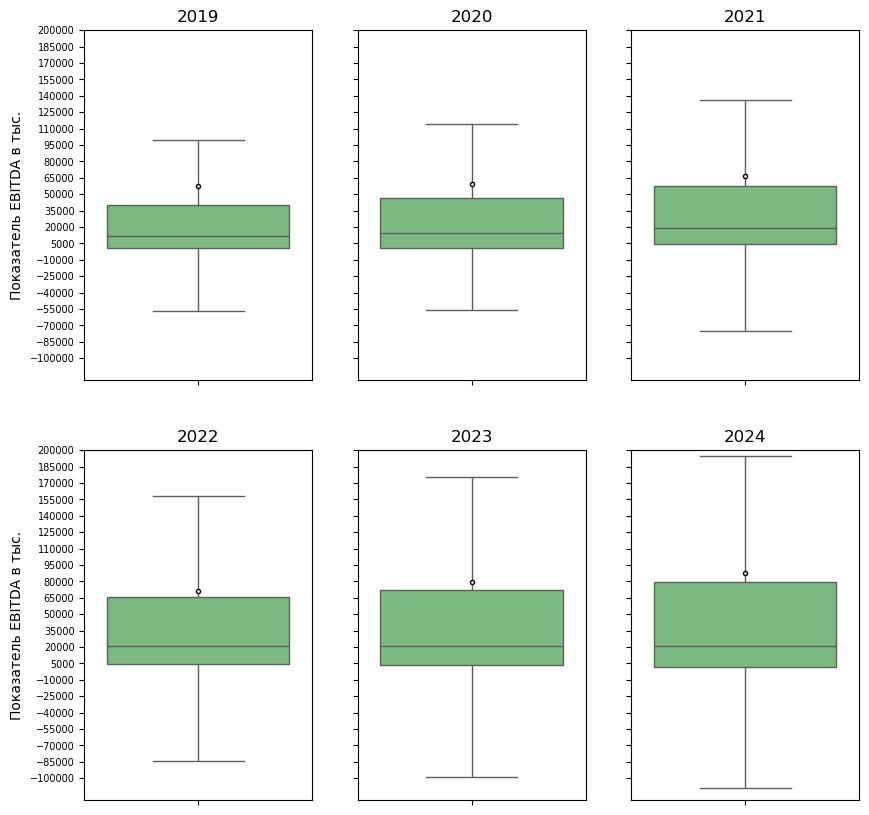

In [416]:
fig, axes = plt.subplots(2,3, sharex = False, sharey=True, figsize = (10,10))
axes = axes.flatten()
for i, year in enumerate(range(2019, 2025)):
    ax = axes[i]
    sns.boxplot(data = ebitda, ax = ax, y = f'EBITDA_{year}', showfliers = False, palette='Greens', \
                showmeans=True, meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"3"})
    ax.set(ylabel="Показатель EBITDA в тыс.")
    ax.set_ylim(-120000, 200000)
    ax.set_yticks(np.linspace(-100000, 200000, 21))
    ax.set_title(year)
    ax.tick_params(axis='both', which='major', labelsize=7)

plt.show()


In [417]:
ebitda_avg_list = [ebitda['EBITDA_2019'].mean(), ebitda['EBITDA_2020'].mean(), ebitda['EBITDA_2021'].mean(),\
                   ebitda['EBITDA_2022'].mean(), ebitda['EBITDA_2023'].mean(), ebitda['EBITDA_2024'].mean()]

ebitda_median_list = [ebitda['EBITDA_2019'].median(), ebitda['EBITDA_2020'].median(), ebitda['EBITDA_2021'].median(),\
                   ebitda['EBITDA_2022'].median(), ebitda['EBITDA_2023'].median(), ebitda['EBITDA_2024'].mean()]


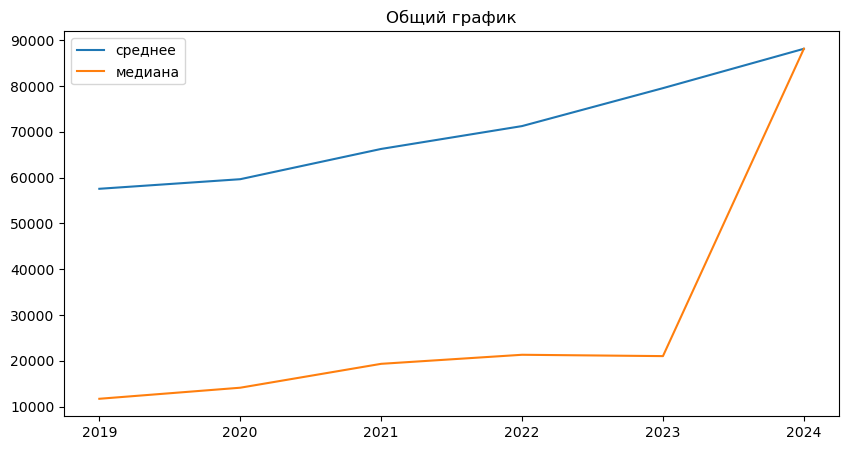

In [418]:
plt.figure(figsize = (10,5))
plt.title('Общий график')
sns.lineplot(x = range(2019, 2025), y = ebitda_avg_list, label = 'среднее')
sns.lineplot(x = range(2019, 2025), y = ebitda_median_list, label = 'медиана')
plt.show()

#### К сожалению данных ранее 2019 года нет, однако на общем графике видно падение в 2019 г. - на этот период пришлось начало эпидемии ковида (конец 2019г. - Январь 2020 г.).
#### Вследствие чего, я предположу, упал спрос на жильё, а изоляция привела к задержкам сдачи проектов (работники на карантине, доставка материалов задерживается)
#### После чего следует медленное восстановление вплоть до резкого подъёма в 2022, согласно среднему, и в 2023, согласно медиане.

#### Огромный размах между медианным и средним значениями (вплоть до 2024 г.) может говорить о том, что более крупные компании восстанавливались быстрее (и скорее всего изначально потеряли меньше), благодаря, возможно, субсидиям.

#### Строительство характеризуется долгосрочными проектами, поэтому финансовые результаты в 2022–2023 годах могут отражать отдачу от работ, начатых ещё до пандемии. Постепенное восстановление после 2019 года и последующий рост подтверждают, что отрасль успешно завершает эти проекты.

#### Исходя из ebitda можно сделать вывод, что строительная отрасль (жилых и нежилых зданий) продемонстрировала способность адаптироваться к чёрным лебедям

### Датафрейм с чистой прибылью и его анализ

In [419]:
profit = builders[['INN', 'org_id', 'profit_2024', 'profit_2023', 'profit_2022', \
                   'profit_2021', 'profit_2020', 'profit_2019']]

In [420]:
# Инфляцию никто не отменял, поэтому рубль 2019 г. != рублю 2024 г. 
# Для дисконтирования возьму данные с сайта ЦБ: https://cbr.ru/hd_base/infl/
# (Значения на момент Декабря каждого года)/100 + 1, чтобы сразу умножать, в 2019г - 1, так как базовый
inflation = [1, 1.049, 1.0839, 1.1194, 1.0742, 1.0952]

deflator = inflation
for i in range (5):
    deflator[i+1] = deflator[i]*deflator[i+1]

In [421]:
for year in range(2019, 2025):
    profit[f'fixed_profit_{year}'] = round(profit[f'profit_{year}'] / deflator[year - 2019], 2)

In [422]:
profit_median_list = [profit['profit_2019'].median(), profit['profit_2020'].median(), profit['profit_2021'].median(), profit['profit_2022'].median(), \
               profit['profit_2023'].median(), profit['profit_2024'].median()]

fixed_profit_median_list = [profit['fixed_profit_2019'].median(), profit['fixed_profit_2020'].median(), profit['fixed_profit_2021'].median(), profit['fixed_profit_2022'].median(), \
               profit['fixed_profit_2023'].median(), profit['fixed_profit_2024'].median()]

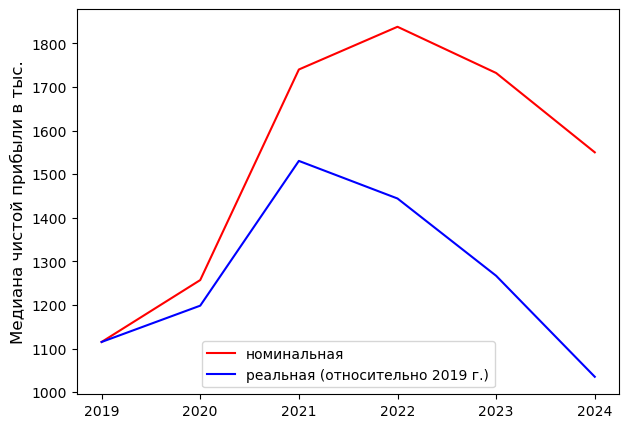

In [423]:
fig, ax = plt.subplots(figsize = (7,5))
sns.lineplot(ax = ax, x = range(2019, 2025), y = profit_median_list, label = 'номинальная', color = 'r',)
sns.lineplot(ax = ax, x = range(2019, 2025), y = fixed_profit_median_list, label = 'реальная (относительно 2019 г.)', color = 'b',)

ax.set_ylabel('Медиана чистой прибыли в тыс.', fontdict = {'size': 12})
plt.show()

In [424]:
for year in range(2020, 2025):
    profit[f'growth_{year}'] = round(((profit[f'profit_{year}'] - profit[f'profit_{year-1}']) \
                                      /  profit[f'profit_{year-1}']), 2) * 100

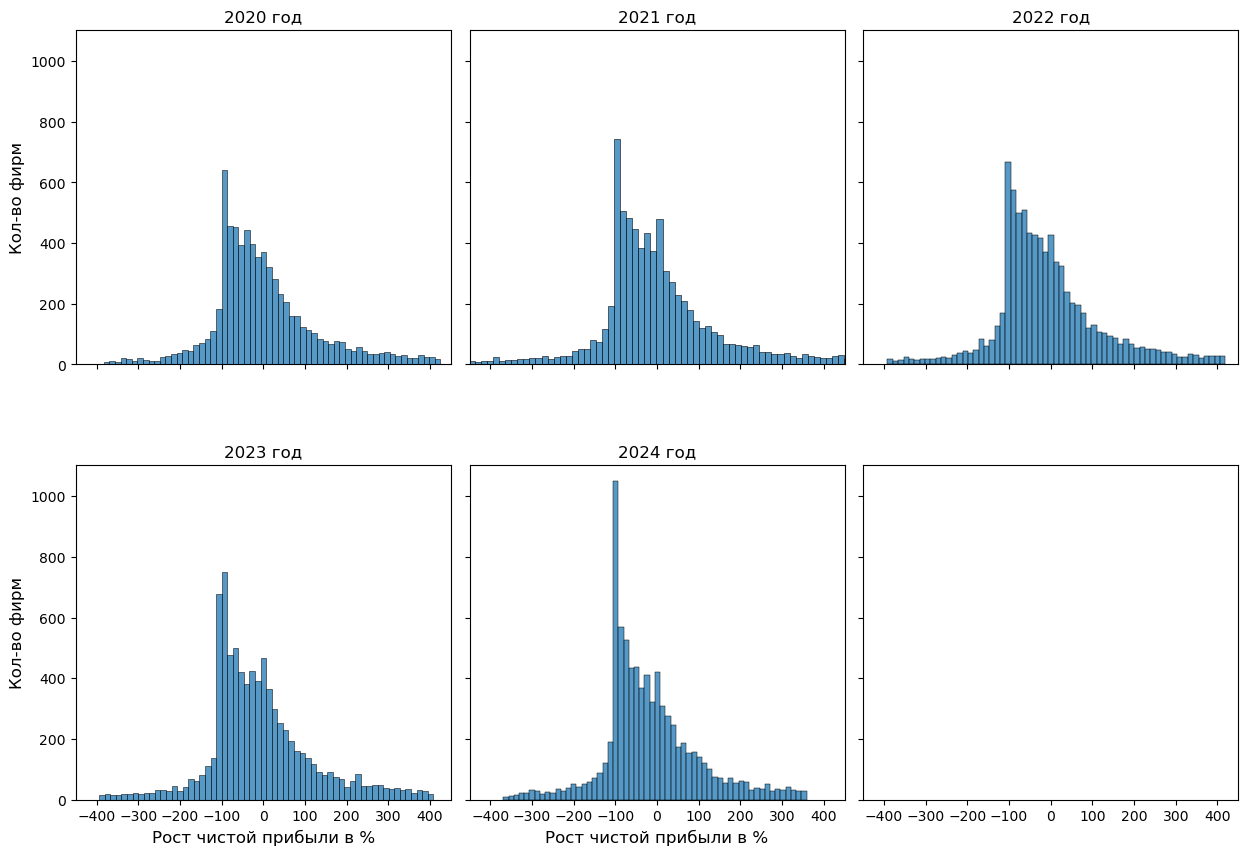

In [425]:
fig, axes = plt.subplots(2,3, sharex = True, sharey=True, figsize = (15,10))
axes = axes.flatten()

for year in range(2020, 2025):
    x = profit[f'growth_{year}']

    # В данных много выбросов - так как некоторые поля делились на ноль
    q1 = x.quantile(0.25)
    q2 = x.quantile(0.75)
    max = q2 + 1.5*(q2 - q1)
    min = q1 - 1.5*(q2 - q1)
    
    x = profit[(x <= max) & (x >= min)][f'growth_{year}']
    ax = axes[year - 2020]
    
    sns.histplot(ax = ax, x = x)
    
    ax.set_xlabel('Рост чистой прибыли в %', fontdict = {'size': 12})
    ax.set_ylabel('Кол-во фирм', fontdict = {'size': 12})
    ax.set_title(f'{year} год')

    ax.set_xlim(-450, 450)
    
plt.subplots_adjust(wspace=0.05, hspace=0.3)  
plt.show()

### Города топ 500 фирм по выручке

In [426]:
top_500 = builders.sort_values(by = 'rev_2024', ascending = False)['address'][:500].tolist()

In [427]:
regions = []
for i in range(500):
    try:
       regions.append(top_500[i].split(',')[1])
       regions.append(top_500[i].split(',')[2])

    except:
        continue

In [428]:
regions = set(regions)

In [429]:
# Адреса написаны вразнобой. Очищенный список снизу получил с помощью гпт
cities = ["Абакан", "Альметьевск", "Архангельск", "Астрахань", "Балашиха", "Белгород", "Березники", "Березовский", 
          "Бердск", "Благовещенск", "Вилючинск", "Владивосток", "Волгоград", "Волжский", "Вологда", "Воронеж", "Грозный", 
          "Губкинский", "Домодедово", "Екатеринбург", "Жуковский", "Ижевск", "Иркутск", "Йошкар-Ола", "Казань", "Калининград", 
          "Калуга", "Каспийск", "Кемерово", "Киров", "Коломна", "Красногорск", "Краснодар", "Красноярск", "Курган", "Курск", "Липецк", 
          "Люберцы", "Магнитогорск", "Москва", "Мытищи", "Нальчик", "Находка", "Нижний Новгород", "Нижний Тагил", "Новосибирск", 
          "Новочебоксарск", "Новый Уренгой", "Обнинск", "Одинцово", "Омск", "Оренбург", "Орёл", "Павловск", "Первоуральск", "Пермь", 
          "Петергоф", "Пушкино", "Раменское", "Ростов-на-Дону", "Рязань", "Салехард", "Самара", "Санкт-Петербург", "Саранск", "Саратов", 
          "Севастополь", "Северодвинск", "Симферополь", "Смоленск", "Солнечногорск", "Сочи", "Ставрополь", "Сургут", "Тамбов", "Тверь", 
          "Тобольск", "Тольятти", "Томск", "Тула", "Тюмень", "Ульяновск", "Урай", "Уфа", "Фокино", "Фрязино", "Хабаровск", "Холмск", "Цивильск", 
          "Чебоксары", "Челябинск", "Чехов", "Чита", "Южно-Сахалинск", "Якутск", "Ялта", "Ярославль"]

In [430]:
response = requests.get('https://raw.githubusercontent.com/Photon74/russian-cities-python/refs/heads/master/russian-cities.json')
city_coordinates = response.json()

In [431]:
# датафрейм с координатами городов из списка
df_city = pd.DataFrame(columns = ['City', 'lat', 'lon'])

for i in range(len(city_coordinates)):
    if city_coordinates[i]['name'] in cities:
        df_city.loc[i] = (city_coordinates[i]['name'], city_coordinates[i]['coords']['lat'], city_coordinates[i]['coords']['lon'])

In [432]:
df_city['lat'] = pd.to_numeric(df_city['lat'])
df_city['lon'] = pd.to_numeric(df_city['lon'])
df_city["geometry"] = df_city.apply(lambda row: Point(row["lon"], row["lat"]), axis=1)
cities_gdf = gpd.GeoDataFrame(df_city, geometry="geometry", crs="EPSG:4326")

In [433]:
# Карта 2021 г. Взята с: https://habr.com/ru/articles/752406/
russia = gpd.read_file('https://github.com/hairymax/offline_russia_plotly/raw/main/data/russia_regions.geojson')
russia = russia.set_crs("EPSG:4326", allow_override=True)

In [434]:
cities_gdf = cities_gdf.to_crs("ESRI:102027")
russia = russia.to_crs("ESRI:102027")

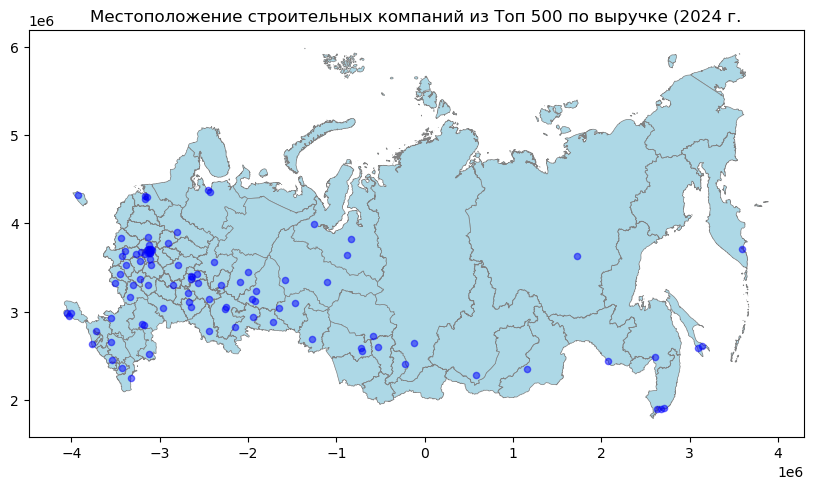

In [435]:
fig, ax = plt.subplots(figsize=(10, 8))

russia.plot(ax=ax, color="lightblue", edgecolor="gray", linewidth=0.5)
cities_gdf.plot(ax=ax, color="blue", markersize=20, marker="o", alpha=0.5)

plt.title("Местоположение строительных компаний из Топ 500 по выручке (2024 г.")
plt.show()

# Выводы
### Из гистограмм видно, что прибыль распределена вокруг нуля - как и предполагалось из различия медианы и среднего - доходы в отрасли распределены неравномерно. Это также можно наблюдать на ящиках с усами, что с кажным годом всё больше расширяются - это может означать, что богатые фирмы стаовятся всё богаче, а бедные терпят всё большие убытки. 

### На карте видно, что крупные (для малых и средних) фирмы тяготеют к богатым и густонаселённым регионам Центральной России - там наблюдается высокий спрос на жильё и коммерческую недвижимость.

### Возможные колебания в 2020 (пандемия) и 2022 (санкции) могли временно снизить рентабельность, но восстановление в 2023–2024 годах говорит об адаптации отрасли к новым условиям.

### Средняя рентабельность, вероятно, умеренная, но зависит от масштаба компании